In [65]:
# Import av bibliotek 
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pandas as pd
import keras_tuner as kt
from keras_tuner import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation
)
from tensorflow.keras.models import Sequential

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import f1_score, accuracy_score

import time

In [2]:
# Kod från uppgiftsbeskrivningen
import numpy as np
from sklearn.datasets import fetch_openml # Importerar fetch_openml för att ladda dataset från OpenML

# Hämtar MNIST-datasetet från OpenML med 784 features, version 1, cachar lokalt och returnerar som numpy-arrays
mnist = fetch_openml("mnist_784", version = 1, cache = True, as_frame = False)
print(mnist.DESCR)

X = mnist["data"]
y = mnist["target"]

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [3]:
# EDA

print(type(y)) # Grundläggande info
print(y.shape)
print(y[:5])   # 5 första
print(y[-5:])  # 5 sista

<class 'numpy.ndarray'>
(70000,)
['5' '0' '4' '1' '9']
['2' '3' '4' '5' '6']


In [4]:
print(type(X)) # Grundläggande info
print(X.shape)
print(X[:5])   # 5 första
print(X[-5:])  # 5 sista

<class 'numpy.ndarray'>
(70000, 784)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


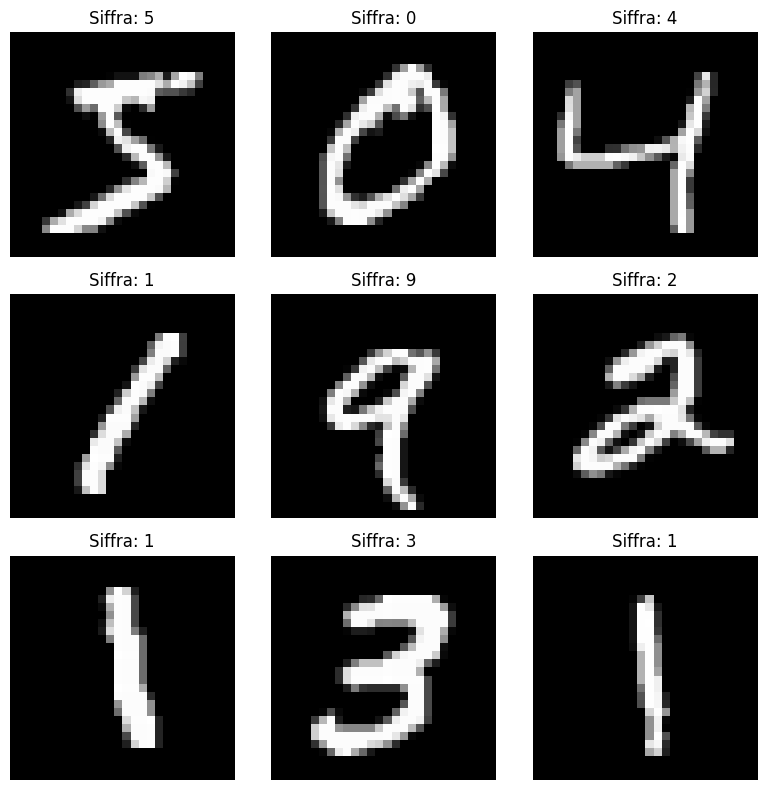

In [33]:
import matplotlib.pyplot as plt

# Skapa ett rutnät för 9 bilder
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    
    # Eftersom X är en numpy-array plockar vi rad i direkt
    # Vi gör om vektorn på 784 till en 28x28 matris
    img = X[i].reshape(28, 28)
    
    plt.imshow(img, cmap='gray')
    plt.title(f"Siffra: {y[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
df = pd.DataFrame(y)

print(df.info())       # Datatyper, antal non-null per kolumn
print(df.describe())   # Statistik: min, max, medel, std osv
print(df.isnull().sum().sum())  # Totalt antal null-värden

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       70000 non-null  object
dtypes: object(1)
memory usage: 547.0+ KB
None
            0
count   70000
unique     10
top         1
freq     7877
0


Inga nullvärden. Konverterar från sträng till integer, krävs för modeller somneurala nätverk där numeriska labels behövs

In [6]:
y = y.astype(int) # Konverterar från sträng till integer,

# Räknar förekomster per siffra (0-9): bincount summerar antal av varje heltal,
# enumerate ger index (siffran) och värde (antal) som loopar igenom och skrivs ut
for digit, count in enumerate(np.bincount(y)):
    print(f"{digit} : {count}")

0 : 6903
1 : 7877
2 : 6990
3 : 7141
4 : 6824
5 : 6313
6 : 6876
7 : 7293
8 : 6825
9 : 6958


Dvs hyfsat jämnt fördelat. 

In [7]:
# Analys av X

print(f"Antal bilder: {X.shape[0]}")          # Antal rader (bilder)
print(f"Pixlar per bild: {X.shape[1]}")        # Antal kolumner (features/pixlar)
print(f"Null-värden: {np.isnan(X).sum()}")     # Kontrollerar saknade värden
print(f"Min-värde: {X.min()}")                 # Lägsta pixelvärde (förväntat 0)
print(f"Max-värde: {X.max()}")                 # Högsta pixelvärde (förväntat 255)
print(f"Unika värden: {np.unique(X).shape[0]}") # Antal unika pixelvärden

Antal bilder: 70000
Pixlar per bild: 784
Null-värden: 0
Min-värde: 0
Max-värde: 255
Unika värden: 256


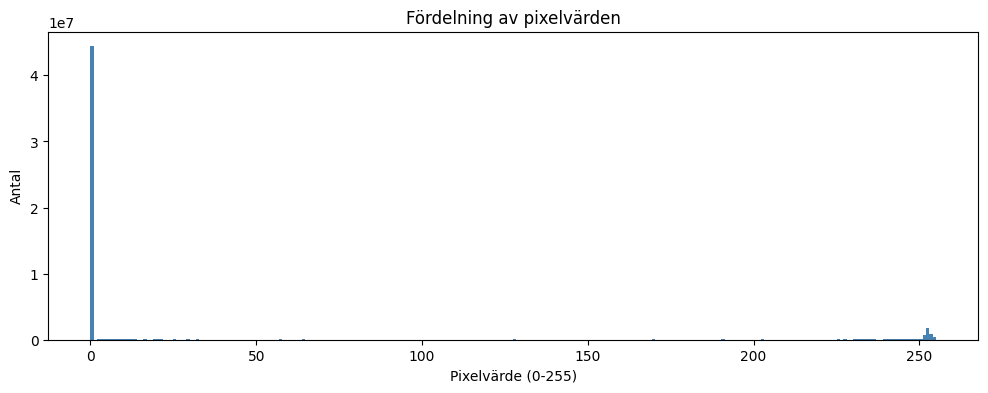

In [8]:
plt.figure(figsize=(12, 4))
plt.hist(X.flatten(), bins=256, range=(0, 255), color="steelblue")
plt.title("Fördelning av pixelvärden")
plt.xlabel("Pixelvärde (0-255)")
plt.ylabel("Antal")
plt.show()

Vi behöver exkludera några toppar för tydlighet i gråskalan.

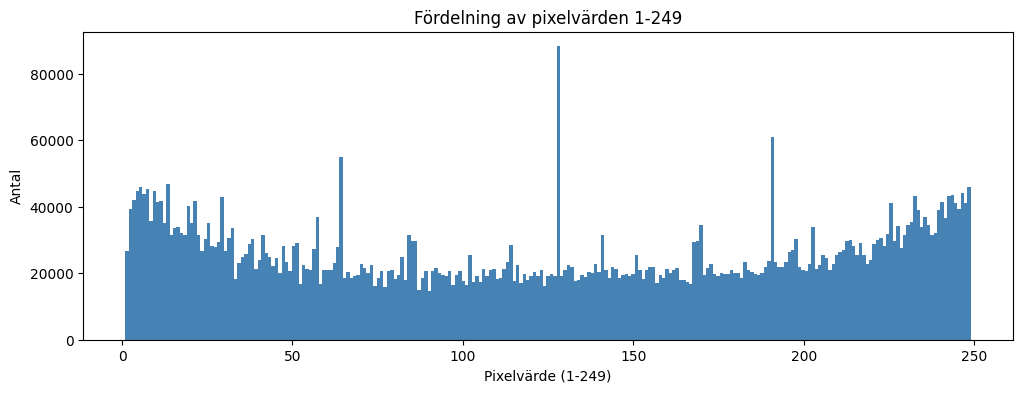

In [9]:
plt.figure(figsize=(12, 4))
plt.hist(X.flatten(), bins=249, range=(1, 249), color="steelblue")  # range=(1,255) exkluderar 0
plt.title("Fördelning av pixelvärden 1-249")
plt.xlabel("Pixelvärde (1-249)")
plt.ylabel("Antal")
plt.show()

Förutom ytterkanter är det hela jämnt fördelat i gråskala.

Att testa senare i kunskapstestet om tid finns är att se vad som händer om man bara använder 2 värden och skippar gråskalan. 

Dela upp i träning (60%), validering (20%) och test (20%)

In [10]:
# Först: 20% till det slutgiltiga testsetet (rör ej förrän sist!)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Sedan: Dela upp resten i träning och validering
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Data uppdelat: Träning {len(X_train)}, Validering {len(X_val)}, Test {len(X_test)}")

Data uppdelat: Träning 42000, Validering 14000, Test 14000


Modellträning:
Tanken är att köra dessa 6 modeller:

Logistisk regression — baseline
Random Forest — ensemble
Support Vector Machine (SVM) — klassisk stark modell
K-Nearest Neighbors (KNN) — enkel men effektiv
Multilayer Perceptron (MLP) — enkelt neuralt nätverk
Convolutional Neural Network (CNN) — optimalt för bilder

Där de 2 sista är neural närverk vi väntar med dem.

Bubblare: Decision Tree, Gradient Boosting / XGBoost

Bygger en konfigureringsdata för att kunna köra : 
Logistisk regression — baseline
Random Forest — ensemble
Support Vector Machine (SVM) — klassisk stark modell
K-Nearest Neighbors (KNN) — enkel men effektiv

För varje sätta:
model: modell och parametrar
params: hyperparametrar att optimera med GridSearchCV

In [20]:
configs = {
    "Logistic Regression": {
        "model": LogisticRegression(
            solver="saga",
            penalty="l2",
            max_iter=300,
            random_state=42,
            n_jobs=-1
        ),
        "param_grid": {
            "clf__C": [0.1, 1, 10],
            "clf__penalty": ["l2"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [16, 32],
            "clf__min_samples_leaf": [1, 2],
            "clf__max_features": ["sqrt"],
            "clf__class_weight": [None]
        }
        },
    "SVM": {
        "model": SVC(),
        "param_grid": {
            "clf__C": [1, 10],
            "clf__kernel": ["rbf"],
            "clf__gamma": ["scale"]
            }
        },
    "KNN": {
    "model": KNeighborsClassifier(),
    "param_grid": {
        "clf__n_neighbors": [3, 5, 7],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [2]
        }
    }
    
}


Träningsdelen

In [18]:
# Jag kör gridsearch på 10% av setet. strafierat urval

X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.10,
    stratify=y_train,
    random_state=42
)


In [21]:
    # Skapar en tom lista för att spara resultat (score, parametrar, namn) från alla modeller vi testar
    all_results = []

    # En variabel som ska hålla i den absolut bästa modellen (vinnaren) efter att loopen är klar
    best_overall_model = None

    # En behållare för det högsta poängvärdet vi hittills stött på (används för att jämföra modeller)
    highest_score = 0

    winner_name = None

    for name, config in configs.items():
        start_time = time.time() # Tajmar körningarna av modellen
        print(f"Kör optimering för: {name}...")
        
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', config['model'])
        ])
        
        grid = GridSearchCV(
            pipe,
            config["param_grid"],
            cv=3,
            scoring="f1_macro",
            n_jobs=-1,
            verbose=2
        )

        grid.fit(X_train_small, y_train_small)
        
        end_time = time.time()
        duration = end_time - start_time
        print(f"Modell: {name} klar på {duration:.2f} sekunder")

        y_val_pred = grid.predict(X_val)
        val_f1 = f1_score(y_val, y_val_pred, average="macro")
        val_accuracy = accuracy_score(y_val, y_val_pred)
        
        all_results.append({
            "Modell": name,
            "Best CV F1": grid.best_score_,
            "Validation F1": val_f1,
            "Validation Accuracy": val_accuracy,
            "Best Params": grid.best_params_,
            "Tid": duration
        })
        
        if val_f1 > highest_score:
            highest_score = val_f1
            best_overall_model = grid.best_estimator_
            winner_name = name

Kör optimering för: Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\Users\janne\anaconda3\envs\dlu_kurs\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Modell: Logistic Regression klar på 171.87 sekunder
Kör optimering för: Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Modell: Random Forest klar på 16.81 sekunder
Kör optimering för: SVM...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Modell: SVM klar på 10.61 sekunder
Kör optimering för: KNN...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Modell: KNN klar på 2.51 sekunder


In [22]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by="Validation F1",
    ascending=False
)

results_df


,Modell,Best CV F1,Validation F1,Validation Accuracy,Best Params,Tid
1,Random Forest,0.928481,0.936083,0.936714,"{'clf__class_weight': None, 'clf__max_depth': ...",16.811319
2,SVM,0.919217,0.928101,0.928214,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke...",10.606904
3,KNN,0.882891,0.896671,0.897929,"{'clf__n_neighbors': 3, 'clf__p': 2, 'clf__wei...",2.512630
0,Logistic Regression,0.886671,0.895631,0.896857,"{'clf__C': 0.1, 'clf__penalty': 'l2'}",171.868464


In [24]:
results_df["Best Params"] = results_df["Best Params"].astype(str)
results_df


,Modell,Best CV F1,Validation F1,Validation Accuracy,Best Params,Tid
1,Random Forest,0.928481,0.936083,0.936714,"{'clf__class_weight': None, 'clf__max_depth': ...",16.811319
2,SVM,0.919217,0.928101,0.928214,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke...",10.606904
3,KNN,0.882891,0.896671,0.897929,"{'clf__n_neighbors': 3, 'clf__p': 2, 'clf__wei...",2.512630
0,Logistic Regression,0.886671,0.895631,0.896857,"{'clf__C': 0.1, 'clf__penalty': 'l2'}",171.868464


In [25]:
results_df.loc[results_df["Modell"] == "Random Forest", "Best Params"].iloc[0]

"{'clf__class_weight': None, 'clf__max_depth': 16, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}"

Då kör vi om den vinnande RandomForest tränings-datan med framtestade parametrar:
{'clf__class_weight': None, 'clf__max_depth': 16, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}

In [ ]:



final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=16,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

# Och analyserar genom att köra modellen på test-datan.

y_test_pred = final_model.predict(X_test)

test_f1 = f1_score(y_test, y_test_pred, average="macro")
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test F1:", test_f1)
print("Test Accuracy:", test_accuracy)

Test F1: 0.9630570824420615
Test Accuracy: 0.9632857142857143


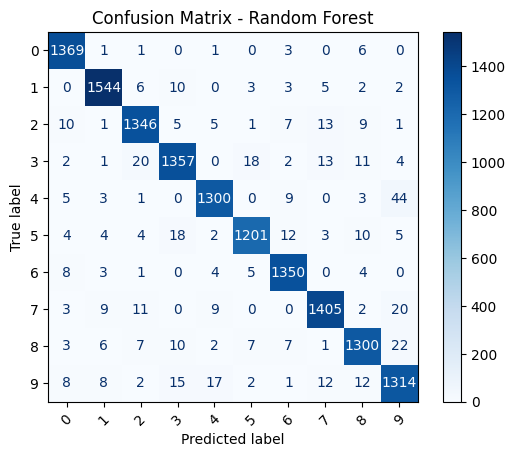

In [28]:
# Confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest")
plt.show()

Att notera från confusion matrix är att det vanligaste felet är att den faktiska siffran "4" prediceras att vara "9" vilket också känns rimligt - dock misstas inte en faktiskt "9" i samma utsträckningn för "4". Att jämföra med att "3" misstas för "5" och "5" för "3" i samma utstäckning.  

Dags att ta fram modeller med neurala nätverk. Dessa tre varianter testas:
- MLP (ANN-variant)
- Vanlig CNN
- CNN med med Dropout/Batch Normalization

Först modifering av datan

In [35]:
# Gör om y till interger

y_train_nn = y_train.astype("int")
y_val_nn = y_val.astype("int")
y_test_nn = y_test.astype("int")

# Skalar X för MLP
X_train_mlp = X_train / 255.0
X_val_mlp = X_val / 255.0
X_test_mlp = X_test / 255.0

# Reshape och skalning för CNN
X_train_cnn = X_train.reshape(-1, 28, 28, 1) / 255.0
X_val_cnn = X_val.reshape(-1, 28, 28, 1) / 255.0
X_test_cnn = X_test.reshape(-1, 28, 28, 1) / 255.0

Definition av MLP och CNN

In [70]:
def build_mlp():
    model = keras.Sequential([
        keras.layers.Input(shape=(784,)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def build_cnn():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def build_cnn_dropout_batchnorm():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Dropout(0.25),

        keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Dropout(0.25),

        keras.layers.Flatten(),

        keras.layers.Dense(128),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



def build_tuned_cnn(hp):
    nn_model = Sequential()
    nn_model.add(Input(shape=(28, 28, 1)))

    # Tune antal filter i första Conv2D-lagret
    filters_1 = hp.Int(
        "filters_1",
        min_value=32,
        max_value=64,
        step=32
    )

    nn_model.add(Conv2D(
        filters=filters_1,
        kernel_size=(3, 3),
        padding="same"
    ))
    nn_model.add(BatchNormalization())
    nn_model.add(Activation("relu"))
    nn_model.add(MaxPooling2D(pool_size=(2, 2)))

    # Tune om dropout ska användas efter första CNN-blocket
    if hp.Boolean("dropout_1"):
        dropout_rate_1 = hp.Choice(
            "dropout_rate_1",
            values=[0.25, 0.4]
        )
        nn_model.add(Dropout(rate=dropout_rate_1))

    # Tune antal filter i andra Conv2D-lagret
    filters_2 = hp.Int(
        "filters_2",
        min_value=64,
        max_value=128,
        step=64
    )

    nn_model.add(Conv2D(
        filters=filters_2,
        kernel_size=(3, 3),
        padding="same"
    ))
    nn_model.add(BatchNormalization())
    nn_model.add(Activation("relu"))
    nn_model.add(MaxPooling2D(pool_size=(2, 2)))

    # Tune om dropout ska användas efter andra CNN-blocket
    if hp.Boolean("dropout_2"):
        dropout_rate_2 = hp.Choice(
            "dropout_rate_2",
            values=[0.25, 0.4]
        )
        nn_model.add(Dropout(rate=dropout_rate_2))

    nn_model.add(Flatten())

    # Tune antal neuroner i Dense-lagret
    dense_units = hp.Int(
        "dense_units",
        min_value=64,
        max_value=128,
        step=64
    )

    nn_model.add(Dense(units=dense_units))
    nn_model.add(BatchNormalization())
    nn_model.add(Activation("relu"))

    # Tune om dropout ska användas i Dense-delen
    if hp.Boolean("dropout_dense"):
        dropout_rate_dense = hp.Choice(
            "dropout_rate_dense",
            values=[0.4, 0.5]
        )
        nn_model.add(Dropout(rate=dropout_rate_dense))

    nn_model.add(Dense(10, activation="softmax"))

    # Tune learning rate
    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.001, 0.0005, 0.0001]
    )

    nn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return nn_model

Dags att köra MLP

In [41]:
# Samlar data för jämförelse

nn_results = []

In [ ]:
# Bygger MLP-modellen
mlp_model = build_mlp()

# Tränar modellen
start_time = time.time()

mlp_history = mlp_model.fit(
    X_train_mlp,
    y_train_nn,
    validation_data=(X_val_mlp, y_val_nn),
    epochs=10,
    batch_size=64,
    verbose=1
)

mlp_duration = time.time() - start_time

# Utvärdera på valideringsdata
mlp_val_loss, mlp_val_accuracy = mlp_model.evaluate(
    X_val_mlp,
    y_val_nn,
    verbose=0
)

print("MLP Validation Loss:", mlp_val_loss)
print("MLP Validation Accuracy:", mlp_val_accuracy)
print("Tid:", mlp_duration)




Epoch 1/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9106 - loss: 0.3131 - val_accuracy: 0.9495 - val_loss: 0.1695
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9594 - loss: 0.1344 - val_accuracy: 0.9636 - val_loss: 0.1210
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9716 - loss: 0.0922 - val_accuracy: 0.9651 - val_loss: 0.1108
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9793 - loss: 0.0694 - val_accuracy: 0.9668 - val_loss: 0.1119
Epoch 5/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9835 - loss: 0.0534 - val_accuracy: 0.9724 - val_loss: 0.0897
Epoch 6/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9867 - loss: 0.0428 - val_accuracy: 0.9736 - val_loss: 0.0908
Epoch 7/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9706 - val_loss: 0.0981
Epoch 8/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9924 - loss: 0.0261 - val_accuracy: 

In [ ]:
# Samla data till tabell

nn_results.append({
    "Modell": "MLP",
    "Validation F1": mlp_val_f1,
    "Validation Accuracy": mlp_val_accuracy,
    "Validation Loss": mlp_val_loss,
    "Tid": mlp_duration
})



In [38]:
mlp_val_pred_prob = mlp_model.predict(X_val_mlp)
mlp_val_pred = np.argmax(mlp_val_pred_prob, axis=1)

mlp_val_f1 = f1_score(y_val_nn, mlp_val_pred, average="macro")

print("MLP Validation F1:", mlp_val_f1)

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MLP Validation F1: 0.9713977745048906


Motsvarande körning av CNN, den metod som på pappret ska vara bäst för bilder.

In [39]:
# Bygg CNN-modellen
cnn_model = build_cnn()

# Träna modellen
start_time = time.time()

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_nn,
    validation_data=(X_val_cnn, y_val_nn),
    epochs=10,
    batch_size=64,
    verbose=1
)

cnn_duration = time.time() - start_time

# Utvärdera på valideringsdata
cnn_val_loss, cnn_val_accuracy = cnn_model.evaluate(
    X_val_cnn,
    y_val_nn,
    verbose=0
)

print("CNN Validation Loss:", cnn_val_loss)
print("CNN Validation Accuracy:", cnn_val_accuracy)
print("Tid:", cnn_duration)


Epoch 1/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9397 - loss: 0.2079 - val_accuracy: 0.9776 - val_loss: 0.0723
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9822 - loss: 0.0591 - val_accuracy: 0.9818 - val_loss: 0.0569
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9870 - loss: 0.0407 - val_accuracy: 0.9854 - val_loss: 0.0515
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9908 - loss: 0.0305 - val_accuracy: 0.9843 - val_loss: 0.0530
Epoch 5/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9858 - val_loss: 0.0441
Epoch 6/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9938 - loss: 0.0198 - val_accuracy: 0.9881 - val_loss: 0.0415
Epoch 7/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9950 - loss: 0.0153 - val_accuracy: 0.9862 - val_loss: 0.0506
Epoch 8/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9967 - loss: 0.0105 - 

In [40]:
cnn_val_pred_prob = cnn_model.predict(X_val_cnn)
cnn_val_pred = np.argmax(cnn_val_pred_prob, axis=1)

cnn_val_f1 = f1_score(y_val_nn, cnn_val_pred, average="macro")

print("CNN Validation F1:", cnn_val_f1)


438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
CNN Validation F1: 0.9874658674106414


In [44]:
# Samla data till tabell

nn_results.append({
    "Modell": "CNN",
    "Validation F1": cnn_val_f1,
    "Validation Accuracy": cnn_val_accuracy,
    "Validation Loss": cnn_val_loss,
    "Tid": cnn_duration
})

CNN med med Dropout/Batch Normalization

In [47]:
cnn_bn_dropout_model = build_cnn_dropout_batchnorm()

start_time = time.time()

cnn_bn_dropout_history = cnn_bn_dropout_model.fit(
    X_train_cnn,
    y_train_nn,
    validation_data=(X_val_cnn, y_val_nn),
    epochs=10,
    batch_size=64,
    verbose=1
)

cnn_bn_dropout_duration = time.time() - start_time

cnn_bn_dropout_val_loss, cnn_bn_dropout_val_accuracy = cnn_bn_dropout_model.evaluate(
    X_val_cnn,
    y_val_nn,
    verbose=0
)

cnn_bn_dropout_val_pred_prob = cnn_bn_dropout_model.predict(X_val_cnn)
cnn_bn_dropout_val_pred = np.argmax(cnn_bn_dropout_val_pred_prob, axis=1)

cnn_bn_dropout_val_f1 = f1_score(
    y_val_nn,
    cnn_bn_dropout_val_pred,
    average="macro"
)

print("CNN + BatchNorm + Dropout Validation Loss:", cnn_bn_dropout_val_loss)
print("CNN + BatchNorm + Dropout Validation Accuracy:", cnn_bn_dropout_val_accuracy)
print("CNN + BatchNorm + Dropout Validation F1:", cnn_bn_dropout_val_f1)
print("Tid:", cnn_bn_dropout_duration)


Epoch 1/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9171 - loss: 0.2794 - val_accuracy: 0.9504 - val_loss: 0.1681
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.9670 - loss: 0.1107 - val_accuracy: 0.9819 - val_loss: 0.0551
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 35s 53ms/step - accuracy: 0.9735 - loss: 0.0891 - val_accuracy: 0.9850 - val_loss: 0.0492
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.9782 - loss: 0.0712 - val_accuracy: 0.9858 - val_loss: 0.0466
Epoch 5/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 36s 55ms/step - accuracy: 0.9800 - loss: 0.0638 - val_accuracy: 0.9871 - val_loss: 0.0392
Epoch 6/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.9813 - loss: 0.0598 - val_accuracy: 0.9889 - val_loss: 0.0361
Epoch 7/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.9844 - loss: 0.0520 - val_accuracy: 0.9890 - val_loss: 0.0357
Epoch 8/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - accuracy: 0.9849 - loss: 0.0477 - 

In [ ]:
# Lägger till i tabellen

nn_results.append({
    "Modell": "CNN + BatchNorm + Dropout",
    "Validation F1": cnn_bn_dropout_val_f1,
    "Validation Accuracy": cnn_bn_dropout_val_accuracy,
    "Validation Loss": cnn_bn_dropout_val_loss,
    "Tid": cnn_bn_dropout_duration
})


Vi gör ett försök att förbättra modellen "CNN + BatchNorm + Dropout Validation" genom att optimera parametrar med KerasTuner, enligt följande:

- Antal filter i första Conv2D-lagret (32, 64)
- Om Dropout används efter första CNN-blocket (True, False)
- Dropout-nivå efter första CNN-blocket (0.25, 0.40)
- Antal filter i andra Conv2D-lagret (64, 128)
- Om Dropout används efter andra CNN-blocket (True, False)
- Dropout-nivå efter andra CNN-blocket (0.25, 0.40)
- Antal neuroner i Dense-lagret (64, 128)
- Om Dropout används i Dense-delen (True, False)
- Dropout-nivå i Dense-delen (0.40, 0.50)
- Learning rate (0.001, 0.0005, 0.0001)


In [71]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

tuner_cnn = RandomSearch(
    build_tuned_cnn,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=1,
    directory="keras_tuner_results",
    project_name="mnist_cnn_tuning",
    overwrite=True
)

tuner_cnn.search(
    X_train_cnn,
    y_train_nn,
    validation_data=(X_val_cnn, y_val_nn),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)



Trial 5 Complete [00h 01m 56s]
val_accuracy: 0.9780714511871338

Best val_accuracy So Far: 0.9893571138381958
Total elapsed time: 01h 25m 10s


In [73]:
# Hämta bästa parametrar

best_cnn_hp = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

print(best_cnn_hp.values)

# Och träna om med dessa

best_tuned_cnn = tuner_cnn.hypermodel.build(best_cnn_hp)

start_time = time.time()

best_tuned_cnn_history = best_tuned_cnn.fit(
    X_train_cnn,
    y_train_nn,
    validation_data=(X_val_cnn, y_val_nn),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

best_tuned_cnn_duration = time.time() - start_time

# Utvärdering

tuned_cnn_val_loss, tuned_cnn_val_accuracy = best_tuned_cnn.evaluate(
    X_val_cnn,
    y_val_nn,
    verbose=0
)

tuned_cnn_val_pred_prob = best_tuned_cnn.predict(X_val_cnn)
tuned_cnn_val_pred = np.argmax(tuned_cnn_val_pred_prob, axis=1)

tuned_cnn_val_f1 = f1_score(
    y_val_nn,
    tuned_cnn_val_pred,
    average="macro"
)

print("Tuned CNN Validation Loss:", tuned_cnn_val_loss)
print("Tuned CNN Validation Accuracy:", tuned_cnn_val_accuracy)
print("Tuned CNN Validation F1:", tuned_cnn_val_f1)
print("Tid:", best_tuned_cnn_duration)



{'filters_1': 32, 'dropout_1': False, 'filters_2': 128, 'dropout_2': False, 'dense_units': 128, 'dropout_dense': True, 'learning_rate': 0.001, 'dropout_rate_dense': 0.4}
Epoch 1/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.9589 - loss: 0.1455 - val_accuracy: 0.9726 - val_loss: 0.0904
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.9824 - loss: 0.0584 - val_accuracy: 0.9862 - val_loss: 0.0451
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 38s 58ms/step - accuracy: 0.9872 - loss: 0.0415 - val_accuracy: 0.9843 - val_loss: 0.0518
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.9908 - loss: 0.0301 - val_accuracy: 0.9844 - val_loss: 0.0515
Epoch 5/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 50s 66ms/step - accuracy: 0.9923 - loss: 0.0268 - val_accuracy: 0.9897 - val_loss: 0.0338
Epoch 6/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 56s 85ms/step - accuracy: 0.9928 - loss: 0.0227 - val_accuracy: 0.9901 - val_loss: 0.0325
Epoch 7/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 46s 70ms/s

In [75]:
# Lägger till i tabellen

nn_results.append({
    "Modell": "Tuned CNN",
    "Validation F1": tuned_cnn_val_f1,
    "Validation Accuracy": tuned_cnn_val_accuracy,
    "Validation Loss": tuned_cnn_val_loss,
    "Tid": best_tuned_cnn_duration
})


Jämför modellerna

In [76]:
nn_results_df = pd.DataFrame(nn_results)

nn_results_df = nn_results_df.sort_values(
    by="Validation F1",
    ascending=False
)

nn_results_df


,Modell,Validation F1,Validation Accuracy,Validation Loss,Tid
3,Tuned CNN,0.990179,0.990143,0.032522,433.314524
2,CNN + BatchNorm + Dropout,0.989409,0.989429,0.033485,362.993736
1,CNN,0.987466,0.987500,0.048816,121.465824
0,MLP,0.971398,0.975214,0.098720,50.762959


Tuning gjorde att vi kom över 0.99 i Validation F1 och Validation accuracy + sänkte validation loss. Detta blir vår slutgiltiga modell som vi kör på test och visar confusion matrix.

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Tuned CNN Test Loss: 0.029746193438768387
Tuned CNN Test Accuracy: 0.9904285669326782
Tuned CNN Test F1: 0.9904344581843365


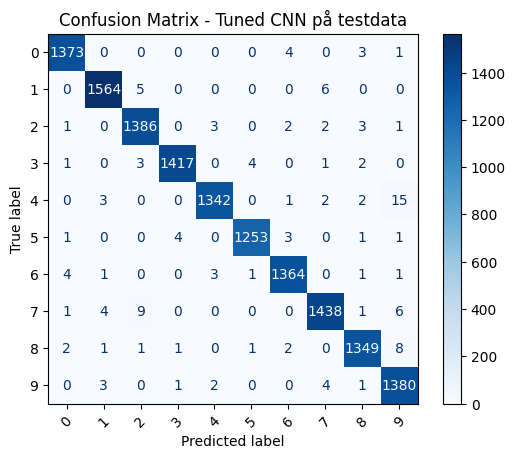

In [77]:
# 1. Kör Tuned CNN på testdata
tuned_cnn_test_loss, tuned_cnn_test_accuracy = best_tuned_cnn.evaluate(
    X_test_cnn,
    y_test_nn,
    verbose=0
)

tuned_cnn_test_pred_prob = best_tuned_cnn.predict(X_test_cnn)
tuned_cnn_test_pred = np.argmax(tuned_cnn_test_pred_prob, axis=1)

tuned_cnn_test_f1 = f1_score(
    y_test_nn,
    tuned_cnn_test_pred,
    average="macro"
)

# 2. Rapportera testresultatet
print("Tuned CNN Test Loss:", tuned_cnn_test_loss)
print("Tuned CNN Test Accuracy:", tuned_cnn_test_accuracy)
print("Tuned CNN Test F1:", tuned_cnn_test_f1)

# 3. Visa confusion matrix
cm = confusion_matrix(y_test_nn, tuned_cnn_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Tuned CNN på testdata")
plt.show()

In [78]:
best_epochs = len(best_tuned_cnn_history.history["loss"])

print("Antal epoker från bästa körningen:", best_epochs)


Antal epoker från bästa körningen: 9


Där det vi har svårast att predicera är en verklig "4" som misstas för "9"; dvs samma problem som vinnaren bland de klassiska ML-metoderna.

Dags att paketera modellen. Vi gör det i följande steg:
1. Omträna om på träningsdata+valideringsdata på bästa modell. Vi väljer de antal epoker som den bästa körningen landade på (9).
2. Utvärdera mot testdata
3. Exportera

In [79]:
# 1
# Slå ihop träningsdata och valideringsdata
X_train_val_cnn = np.concatenate([X_train_cnn, X_val_cnn], axis=0)
y_train_val_nn = np.concatenate([y_train_nn, y_val_nn], axis=0)

print(X_train_val_cnn.shape)
print(y_train_val_nn.shape)

# Bygg en ny modell med bästa hyperparametrarna
final_tuned_cnn = tuner_cnn.hypermodel.build(best_cnn_hp)

# Träna på test+validation

final_tuned_cnn = tuner_cnn.hypermodel.build(best_cnn_hp)

start_time = time.time()

final_tuned_cnn_history = final_tuned_cnn.fit(
    X_train_val_cnn,
    y_train_val_nn,
    epochs=best_epochs,
    batch_size=64,
    verbose=1
)

final_tuned_cnn_duration = time.time() - start_time


(56000, 28, 28, 1)
(56000,)
Epoch 1/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - accuracy: 0.9649 - loss: 0.1249
Epoch 2/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step - accuracy: 0.9841 - loss: 0.0525
Epoch 3/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 88s 58ms/step - accuracy: 0.9876 - loss: 0.0404
Epoch 4/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.9905 - loss: 0.0307
Epoch 5/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 88s 68ms/step - accuracy: 0.9919 - loss: 0.0256
Epoch 6/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.9930 - loss: 0.0216
Epoch 7/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9939 - loss: 0.0192
Epoch 8/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step - accuracy: 0.9945 - loss: 0.0166
Epoch 9/9
875/875 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9952 - loss: 0.0141


In [81]:
# Utvärdera mot testdata
final_test_loss, final_test_accuracy = final_tuned_cnn.evaluate(
    X_test_cnn,
    y_test_nn,
    verbose=0
)

# Skapa prediktioner
final_test_pred_prob = final_tuned_cnn.predict(X_test_cnn)

# Gör om sannolikheter till klassnummer 0-9
final_test_pred = np.argmax(final_test_pred_prob, axis=1)

# Beräkna F1
final_test_f1 = f1_score(
    y_test_nn,
    final_test_pred,
    average="macro"
)

print("Final Tuned CNN Test Loss:", final_test_loss)
print("Final Tuned CNN Test Accuracy:", final_test_accuracy)
print("Final Tuned CNN Test F1:", final_test_f1)


438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Final Tuned CNN Test Loss: 0.02782447636127472
Final Tuned CNN Test Accuracy: 0.9922142624855042
Final Tuned CNN Test F1: 0.9922181530713724


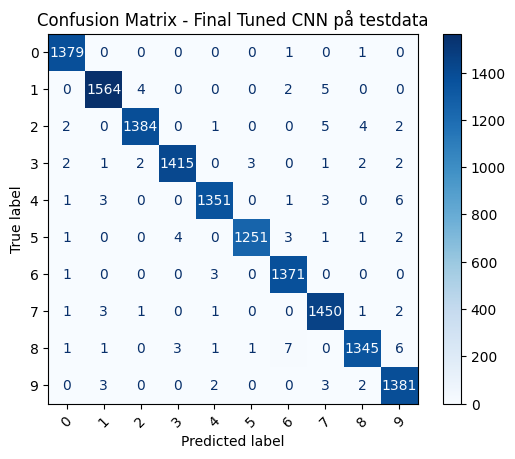

In [82]:
# Confusion matrix

cm = confusion_matrix(y_test_nn, final_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Final Tuned CNN på testdata")
plt.show()


In [86]:
# Allmän info kring modellen

final_tuned_cnn.summary()
final_tuned_cnn.input_shape

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,526,944 (9.64 MB)

 Trainable params: 842,122 (3.21 MB)

 Non-trainable params: 576 (2.25 KB)

 Optimizer params: 1,684,246 (6.42 MB)

(None, 28, 28, 1)

In [87]:
# 3 Spara och export

final_tuned_cnn.save("mnist_tuned_cnn.keras")

